In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 80                  # アンサンブルメンバー数
p = 40                  # 観測点の数 (今回は全点観測なので N と同じ)

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

In [2]:
# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成 (kadai5準拠)
# =====================================================================

def lorenz96(x, F):
    # x の shape が (N,) でも (N, m) でも、axis=0で一括計算
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    # ルンゲ・クッタ法も全メンバーを並列一括処理
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 0.001 # カオス誘発用の摂動

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)  # dtステップで1回の積分
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

# [変更点] モダンな乱数生成器 (default_rng) を使用
rng_obs = np.random.default_rng(seed=67) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)  # 各変数ごとに平均0に調整
y_o_data = true_states + noise # 観測データ y^o

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


In [6]:
# =====================================================================
# 3. LETKFの実装 (Adaptive Multiplicative Inflation 組み込み版)
# =====================================================================
import time
import numpy as np
import matplotlib.pyplot as plt

# (R_localization_inv 関数はそのまま使用)
def R_localization_inv(sigma):
    R_loc_inv = np.zeros((N, N))
    def L(d):
        if d < np.sqrt(10 / 3) * sigma * 2.0:
            return np.exp(- (d**2) / (2 * sigma**2))
        else:
            return 0.0
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            orig_r_inv = 1.0 / R_mat[j, j]
            R_loc_inv[i, j] = orig_r_inv * L(d)
    return R_loc_inv

def run_LETKF_Adaptive(y_o_data, true_states, init_v_b, init_delta, sigma):
    num_cycles = y_o_data.shape[0]
    R_loc_inv = R_localization_inv(sigma)
    
    record_rmse = np.zeros(num_cycles)
    record_spread = np.zeros(num_cycles)
    record_mean_delta = np.zeros(num_cycles) # 動く delta の平均を記録
    
    # 初期アンサンブルの生成
    rng_enkf = np.random.default_rng(seed=42)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)
    
    # 動的インフレーションの初期化
    delta_array = np.full(N, init_delta)
    v_b = np.full(N, init_v_b) # 不確実性の初期値 (0.05^2 = 0.0025)
    
    start_time = time.time()
    for t in range(num_cycles):
        y_o = y_o_data[t]
        
        # [Step 1: 背景予測]
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        
        # 配列化された inflation で Z^b を構築
        inflation_factor = np.sqrt(1.0 + delta_array) / np.sqrt(m - 1.0)
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor[:, None]
        
        Y_b = H_mat @ Z_b
        innovation = y_o - H_mat @ x_b_mean
        
        # [Step 2: 局所解析]
        X_a = np.zeros((N, m))
        
        # このステップ中に更新された delta を一時保存する配列 (一斉更新用)
        delta_array_next = np.zeros(N)
        
        for i in range(N):
            R_loc_inv_diag = np.diag(R_loc_inv[i, :])
            P_a_tilde_inv = np.eye(m) + (Y_b.T @ R_loc_inv_diag @ Y_b)
            D, C = np.linalg.eigh(P_a_tilde_inv)
            
            P_a_tilde = C @ np.diag(1.0 / D) @ C.T
            W = C @ np.diag(1.0 / np.sqrt(D)) @ C.T
            w = P_a_tilde @ Y_b.T @ R_loc_inv_diag @ innovation
            T = w[:, None] + np.sqrt(m - 1.0) * W
            X_a[i, :] = x_b_mean[i] + Z_b[i, :] @ T
            
            # --- Adaptive Inflation (Miyoshi 2011) ---
            # 局所化された実効観測数 p
            p_loc = np.trace(R_loc_inv_diag)
            
            # 分子 (mole): d^o_b^T * R^-1 * d^o_b - p
            # innovation は (N,) の 1D ベクトルなので、そのまま @ で内積計算
            mole = (innovation.T @ R_loc_inv_diag @ innovation) - p_loc
            
            # 分母 (deno): trace(HBH^T * R^-1)
            # trace(Y_b @ Y_b^T @ R_loc_inv_diag) はトレースの巡回不変性により
            # trace(Y_b^T @ R_loc_inv_diag @ Y_b) と計算する方が次元が小さく (m x m) 高速です
            deno = np.trace(Y_b.T @ R_loc_inv_diag @ Y_b)
            
            if deno > 1e-10: # ゼロ除算防止
                delta_o_i = mole / deno
                # スライド133の v^o_i の式
                v_o_i = (2.0 / p_loc) * (delta_array[i] * deno + p_loc)**2 / (deno**2)
            else:
                delta_o_i = 0.0
                v_o_i = 1e10 # denoが小さすぎる場合は観測の不確実性を無限大にして更新を無視
            
            # ベイズ更新 (スライド132)
            delta_a = (delta_array[i] * v_o_i + delta_o_i * v_b[i]) / (v_o_i + v_b[i])
            
            # クリップ (0.0 未満にならないようにする。上限も念のため 3.0 くらいに設定)
            delta_array_next[i] = np.clip(delta_a, 0.0, 3.0)
            
        # 次のステップのために delta_array を一斉更新
        delta_array = delta_array_next.copy()
        
        # [Step 3: 記録]
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        record_spread[t] = np.sqrt(np.mean(np.var(X_a, axis=1, ddof=1)))
        record_mean_delta[t] = np.mean(delta_array) # どのようにδが育ったか平均を記録
        
    print(f"LETKF(Adaptive) 実行時間: {time.time() - start_time:.4f} 秒")
    return record_rmse, record_spread, record_mean_delta

# --- 実行とテスト ---
# 最初は適当な値 (0.01) からスタートさせ、自律的に育つかを見る
rmse_letkf, spread_letkf, mean_delta = run_LETKF_Adaptive(y_o_data, true_states, init_v_b=0.04**2, init_delta=0.01, sigma=3.0)

# プロットで確認
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(rmse_letkf, label='LETKF RMSE', color='green', alpha=0.8)
ax1.plot(spread_letkf, label='LETKF Spread', color='black', linestyle='--', alpha=0.8)
ax1.set_xlabel('Time (cycles)')
ax1.set_ylabel('RMSE / Spread')
ax1.grid(True, linestyle='--', alpha=0.5)

# 動的な delta の変化を右軸にプロット
ax2 = ax1.twinx()
ax2.plot(mean_delta, label='Mean Inflation (\delta)', color='red', alpha=0.6)
ax2.set_ylabel('Inflation factor (\delta)')

fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.85))
plt.title('LETKF with Adaptive Inflation')
plt.show()

<>:130: SyntaxWarning: invalid escape sequence '\d'
<>:131: SyntaxWarning: invalid escape sequence '\d'
<>:130: SyntaxWarning: invalid escape sequence '\d'
<>:131: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hanha\AppData\Local\Temp\ipykernel_17732\3513789784.py:130: SyntaxWarning: invalid escape sequence '\d'
  ax2.plot(mean_delta, label='Mean Inflation (\delta)', color='red', alpha=0.6)
C:\Users\hanha\AppData\Local\Temp\ipykernel_17732\3513789784.py:131: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_ylabel('Inflation factor (\delta)')


KeyboardInterrupt: 

In [ ]:
# 平均値を出力
print(f"平均RMSE: {np.mean(rmse_letkf):.4f}")
print(f"平均Spread: {np.mean(spread_letkf):.4f}")

平均RMSE: 0.3952
平均Spread: 0.5077


<>:138: SyntaxWarning: invalid escape sequence '\d'
<>:139: SyntaxWarning: invalid escape sequence '\d'
<>:138: SyntaxWarning: invalid escape sequence '\d'
<>:139: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hanha\AppData\Local\Temp\ipykernel_27688\4100246322.py:138: SyntaxWarning: invalid escape sequence '\d'
  ax2.plot(mean_delta, label='Mean Inflation (\delta)', color='red', alpha=0.6)
C:\Users\hanha\AppData\Local\Temp\ipykernel_27688\4100246322.py:139: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_ylabel('Inflation factor (\delta)')


LETKF(Miyoshi2011 Adaptive) 実行時間: 77.8765 秒


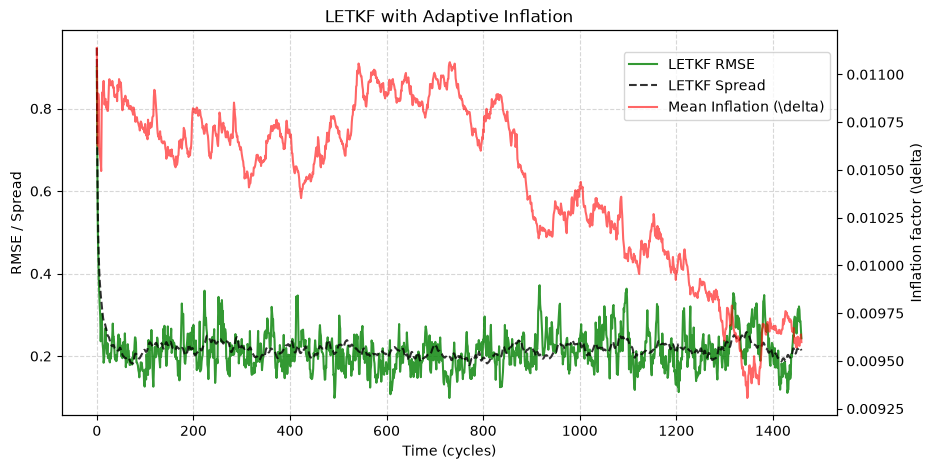

In [ ]:
import numpy as np
import time

def run_LETKF_Adaptive_Miyoshi2011(y_o_data, true_states, init_v_b, init_delta, sigma):
    num_cycles = y_o_data.shape[0]
    
    # 事前準備: 各グリッド点 i から各観測点 j への純粋な局所化重み行列 W_weights (N x N) を作成
    # (R_loc_inv から逆算するのではなく、直接重み関数 L(d) を保持する)
    W_weights = np.zeros((N, N))
    def L(d):
        if d < np.sqrt(10 / 3) * sigma * 2.0:
            return np.exp(- (d**2) / (2 * sigma**2))
        else:
            return 0.0
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            W_weights[i, j] = L(d)

    # 観測誤差の対角成分 (R_j) を取得
    R_diag = np.diag(R_mat)
    
    record_rmse = np.zeros(num_cycles)
    record_spread = np.zeros(num_cycles)
    record_mean_delta = np.zeros(num_cycles)
    
    # 初期アンサンブルの生成
    rng_enkf = np.random.default_rng(seed=42)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)
    
    # 動的インフレーションの初期化 (α = 1 + δ として管理)
    delta_array = np.full(N, init_delta)
    v_b = np.full(N, init_v_b) # 事前分散 v^b
    
    start_time = time.time()
    for t in range(num_cycles):
        y_o = y_o_data[t]
        
        # [Step 1: 背景予測]
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        
        # 現在の delta_array からインフレーションを適用して Z^b を構築
        inflation_factor = np.sqrt(1.0 + delta_array) / np.sqrt(m - 1.0)
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor[:, None]
        
        Y_b = H_mat @ Z_b
        innovation = y_o - H_mat @ x_b_mean
        
        # 全観測点における膨張前の背景誤差分散 (H P^f H^T)_j の対角成分を計算
        # ※ Y_b はすでにインフレーション(1+δ)が掛かっているので、割って元の P^f ベースに戻す
        H_Pf_H_T_diag = np.sum(Y_b**2, axis=1) / (1.0 + delta_array)
        
        # [Step 2: 局所解析]
        X_a = np.zeros((N, m))
        delta_array_next = np.zeros(N)
        
        for i in range(N):
            # LETKF用の局所化された R^-1 の構築 (既存の処理)
            w_i = W_weights[i, :]
            R_loc_inv_diag = w_i / R_diag
            R_loc_inv_diag_mat = np.diag(R_loc_inv_diag)
            
            # LETKFの通常の解析更新
            P_a_tilde_inv = np.eye(m) + (Y_b.T @ R_loc_inv_diag_mat @ Y_b)
            D, C = np.linalg.eigh(P_a_tilde_inv)
            P_a_tilde = C @ np.diag(1.0 / D) @ C.T
            W = C @ np.diag(1.0 / np.sqrt(D)) @ C.T
            w_vec = P_a_tilde @ Y_b.T @ R_loc_inv_diag_mat @ innovation
            T = w_vec[:, None] + np.sqrt(m - 1.0) * W
            X_a[i, :] = x_b_mean[i] + Z_b[i, :] @ T
            
            # --- Miyoshi (2011) 厳密準拠の Adaptive Inflation ---
            # ゼロ除算を防ぐため、H_Pf_H_T_diag が有効な要素のみで計算
            valid = H_Pf_H_T_diag > 1e-10
            
            if np.sum(w_i[valid]) > 1e-10:
                # 論文式(14)の分子・分母を要素ごとに計算して重み w_j を掛ける
                # インフレーション係数 α^o の推定
                mole_alpha = w_i[valid] * (innovation[valid]**2 - R_diag[valid]) / H_Pf_H_T_diag[valid]
                deno_alpha = w_i[valid]
                
                alpha_o_i = np.sum(mole_alpha) / np.sum(deno_alpha)
                delta_o_i = alpha_o_i - 1.0  # α = 1 + δ より
                
                # 論文式(15)に基づく観測分散 v^o の計算
                # 実際の真の α の代わりに事前推定値 (1.0 + delta_array[i]) を使用
                alpha_b_i = 1.0 + delta_array[i]
                
                mole_v = w_i[valid] * ((alpha_b_i * H_Pf_H_T_diag[valid] + R_diag[valid]) / H_Pf_H_T_diag[valid])**2
                deno_v = (np.sum(w_i[valid]))**2
                
                v_o_i = 2.0 * np.sum(mole_v) / deno_v
            else:
                delta_o_i = 0.0
                v_o_i = 1e10
            
            # ガウスアプローチ（カルマンフィルタ）によるベイズ更新 (式6)
            # 事前値 delta_array[i] と 観測からの推定値 delta_o_i の最小分散全合成
            k_gain = v_b[i] / (v_b[i] + v_o_i)
            delta_a = delta_array[i] + k_gain * (delta_o_i - delta_array[i])
            
            # 負のインフレーション（デフレ）を許容しつつ、極端な値をクリップ
            delta_array_next[i] = np.clip(delta_a, 0.0, 3.0)
            
        # 次のステップのために delta_array を一斉更新
        delta_array = delta_array_next.copy()
        
        # [Step 3: 記録]
        x_a_mean = np.mean(X_a, axis=1)
        record_rmse[t] = np.sqrt(np.mean((x_a_mean - true_states[t])**2))
        record_spread[t] = np.sqrt(np.mean(np.var(X_a, axis=1, ddof=1)))
        record_mean_delta[t] = np.mean(delta_array)
        
    print(f"LETKF(Miyoshi2011 Adaptive) 実行時間: {time.time() - start_time:.4f} 秒")
    return record_rmse, record_spread, record_mean_delta

# --- 実行とテスト ---
# 最初は適当な値 (0.01) からスタートさせ、自律的に育つかを見る
rmse_letkf, spread_letkf, mean_delta = run_LETKF_Adaptive_Miyoshi2011(y_o_data, true_states, init_v_b=0.04**2, init_delta=0.01, sigma=3.0)

# プロットで確認
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(rmse_letkf, label='LETKF RMSE', color='green', alpha=0.8)
ax1.plot(spread_letkf, label='LETKF Spread', color='black', linestyle='--', alpha=0.8)
ax1.set_xlabel('Time (cycles)')
ax1.set_ylabel('RMSE / Spread')
ax1.grid(True, linestyle='--', alpha=0.5)

# 動的な delta の変化を右軸にプロット
ax2 = ax1.twinx()
ax2.plot(mean_delta, label='Mean Inflation (\delta)', color='red', alpha=0.6)
ax2.set_ylabel('Inflation factor (\delta)')

fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.85))
plt.title('LETKF with Adaptive Inflation')
plt.show()

In [ ]:
# 平均値を出力
print(f"平均RMSE: {np.mean(rmse_letkf):.4f}")
print(f"平均Spread: {np.mean(spread_letkf):.4f}")

平均RMSE: 0.2139
平均Spread: 0.2175
